# Blog Genrate

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict 
from dotenv import load_dotenv

e:\Langgraph\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
import os

In [3]:
api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=api_key, model="llama-3.1-8b-instant")

In [4]:
class BlogState(TypedDict):

    title : str
    outline : str
    blog : str
    # evaluator : str
    score: str

In [5]:
def genrate_outline(state: BlogState) -> BlogState:
    
    title=state['title']

    prompt=f"Genrate The detailes Outline of a blog on This topic {title}"

    outline= llm.invoke(prompt).content

    state['outline']=outline
    
    return state

In [6]:
def genrate_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt=f"write a detailes blog on the topic - {title} using the following outline \n {outline}"

    content = llm.invoke(prompt).content

    state['blog'] = content   
     
    return state

In [ ]:
def Score_evaluate(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']
    # evaluator = state['evaluator']

    prompt=f"Genrate the only score out of 10, based on this outline- {outline} & title - {title} Not Extra Information"

    score = llm.invoke(prompt).content

    state['score'] = score.strip()

    return state

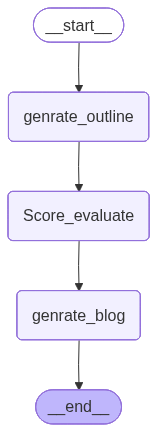

In [8]:
graph = StateGraph(BlogState)

# add Nodes
graph.add_node('genrate_outline', genrate_outline)
graph.add_node('genrate_blog', genrate_blog)
graph.add_node('Score_evaluate', Score_evaluate)

# add Edges
graph.add_edge(START, 'genrate_outline')
graph.add_edge('genrate_outline', 'Score_evaluate')
graph.add_edge('Score_evaluate', 'genrate_blog')
graph.add_edge('genrate_blog', END)

# compile
workflow = graph.compile()
workflow

In [13]:
## Execute
initial_state = {'title': 'TATA Group Of Company \n ' ,"evaluator": "AI_Evaluator"}

final_state = workflow.invoke(initial_state)

print("\n Final Blog Output:")
print(final_state['blog'])

print("\n" + "-"*100)

print("\n Evaluation Score:")
print(final_state['score'])

print("\n" + "-"*100)

print("\n Outlines :")
print(final_state['outline'])


 Final Blog Output:
**The TATA Group: A Legacy of Innovation and Excellence**

**I. Introduction**

The TATA Group is one of India's most iconic and respected business conglomerates, with a rich history spanning over 155 years. Founded by Jamsetji Tata in 1868, the group has grown from a small trading firm to a global business empire with a diverse portfolio of companies and brands. Today, the TATA Group is a significant player in the Indian economy and a major force in the global business landscape. With a strong commitment to innovation and excellence, the group has established itself as a leader in various industries, including steel, automotive, information technology, consumer products, and more. This blog post will explore the history of the TATA Group, its business portfolio, sustainability initiatives, and future prospects.

**II. History of the TATA Group**

The TATA Group's story began in 1868 when Jamsetji Tata, a Parsi entrepreneur from Gujarat, started a small trading fir

In [11]:
print("the Outlines is ")
print("-------------------------")
print(final_state['outline'])

the Outlines is 
-------------------------
**Title:** "Unveiling the Legacy of Tata Group: A Comprehensive Overview of One of India's Largest Conglomerates"

**I. Introduction**

- Briefly introduce the Tata Group and its significance in India's business landscape
- Mention the purpose of the blog: to provide an in-depth look at the Tata Group's history, business operations, and achievements

**II. History of Tata Group**

- Early beginnings: Jamsetji Tata's vision and entrepreneurial spirit
- Key milestones:
  - Establishment of the Tata Steel company in 1907
  - Tata Engineering and Locomotive Company (TELCO) founded in 1945
  - Tata Motors becomes a subsidiary of TELCO in 1961
  - Tata Consultancy Services (TCS) founded in 1968
- Expansion and diversification under the leadership of Ratan Tata

**III. Business Operations**

- **Tata Steel:** Overview of the company's history, products, and global presence
- **Tata Motors:** Discussion of the company's automotive business, including 